# Paired training pilot on a geographic roof split

**Stage 2 scientific report.** This notebook evaluates whether ImageNet encoder initialization changes learning under limited roof labels when architecture, data order, augmentation and update budget are paired. It reads completed run artifacts; no cell starts training.

## 1. Research question and evaluation design

We compare a U-Net with an EfficientNet-B0 encoder initialized either fully at random or from the original torchvision ImageNet-1K weights. A U-Net combines a downsampling **encoder**, which extracts increasingly abstract features, with an upsampling decoder that restores pixel-level resolution. Both variants use a fresh decoder with identical initial weights within each training-size pair.

The active split holds out one compact southwest test area and a northern validation area. This pilot uses only Seed 17 training subsets of 25, 100 and 500 images. The 259 test images are absent from training, checkpoint selection and examples. Three test images were used in a discarded old-split pilot; every model reported here nevertheless starts fresh, and the old results did not set the new boundary or training recipe.

### Fixed method

Images remain at 512 × 512 pixels. Joint D4 augmentation applies a horizontal reflection and a multiple-of-90° rotation to image and binary target. Both initializations use fixed ImageNet normalization. The objective is an equal mixture of pixel-averaged binary cross-entropy and per-image soft Dice loss. **IoU** (intersection over union) measures thresholded overlap as intersection area divided by union area; **Dice** uses twice the intersection divided by predicted plus reference area. Empty reference and prediction score 1, while false positives against an empty reference score 0. Per-image average precision (AP) is averaged only across images containing roof pixels.

AdamW uses learning rate 3×10⁻⁴ and weight decay 10⁻⁴, excluding biases and normalization parameters. All parameters and BatchNorm affine terms are trainable; running BatchNorm statistics update during training and are fixed during evaluation. Each run receives 2,000 optimizer updates, with validation before training and every 100 updates. The selected trained checkpoint has the highest mean per-image validation IoU at threshold 0.5; earlier updates win ties. There is no scheduler or early stopping.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
SPLITS = json.loads((ROOT / "data/metadata/splits.json").read_text())
RESULTS = pd.read_csv(ROOT / "reports/training_pilot_results.csv")
HISTORY = pd.read_csv(ROOT / "reports/training_pilot_history.csv")

In [2]:
split_table = pd.DataFrame({
    "role": SPLITS["counts"].keys(),
    "images": SPLITS["counts"].values(),
})
subset_sizes = {
    name: len(ids)
    for name, ids in SPLITS["training_subsets"]["repetitions"]["1"]["subsets"].items()
}
display(split_table.style.hide(axis="index"), pd.Series(subset_sizes, name="images"))

role,images
training,1210
validation,289
test,259
excluded,122


25        25
50        50
100      100
250      250
500      500
full    1210
Name: images, dtype: int64

The roles contain no positive-area cross-role footprint overlap. Validation labels are additional to each stated training-label budget. Multiple nearby or overlapping views inside a role can still be correlated, and all regions come from Wartenberg; the experiment therefore studies within-town geographic transfer rather than generalization to a new city.

## 2. Selected-checkpoint results

The primary result is equally weighted mean per-image validation IoU. Dice and AP are secondary views of overlap and ranking. Runtime includes the repeated validation passes and final matched train/validation evaluation. Effective data passages divide processed examples by the number of distinct labelled training images; augmented views do not count as new labels.

In [3]:
columns = {
    "training_size": "labels", "initialization": "initialization",
    "best_step": "best step", "validation_iou": "val IoU",
    "validation_dice": "val Dice", "validation_ap": "val AP",
    "validation_ap_images": "AP images", "examples_processed": "examples",
    "data_passages": "data passages", "total_minutes": "minutes",
}
display(RESULTS[list(columns)].rename(columns=columns).style.format({
    "val IoU": "{:.3f}", "val Dice": "{:.3f}", "val AP": "{:.3f}",
    "data passages": "{:.1f}", "minutes": "{:.1f}",
}).hide(axis="index"))

labels,initialization,best step,val IoU,val Dice,val AP,AP images,examples,data passages,minutes
25,imagenet,400,0.834,0.904,0.946,288,7145,285.8,12.2
25,random,2000,0.785,0.871,0.924,288,7145,285.8,12.3
100,imagenet,1400,0.862,0.923,0.960,288,8000,80.0,13.2
100,random,1700,0.813,0.892,0.957,288,8000,80.0,13.1
500,imagenet,1600,0.870,0.927,0.975,288,8000,16.0,13.6
500,random,1800,0.826,0.900,0.964,288,8000,16.0,13.5


ImageNet initialization produced the highest selected validation IoU at every label budget: 0.834, 0.862 and 0.870 for 25, 100 and 500 images, compared with 0.785, 0.813 and 0.826 from random initialization. The six runs took 77.9 minutes in total, including evaluation; 61.8 minutes were spent in optimization. Mean AP uses 288 of the 289 validation images because the one empty reference mask is excluded by the declared AP convention.

The fixed 2,000-update budget exposes each 25-image subset to about 285.8 effective data passages, versus 80.0 at 100 images and 16.0 at 500. Performance therefore cannot be read as a controlled comparison at equal numbers of data passages.

## 3. Learning trajectories

The upper panels show validation IoU at the predeclared evaluations. The lower panels show the mean augmented training objective over each preceding 100-update interval. These losses are useful for optimization diagnostics but are not directly comparable with unaugmented validation loss.

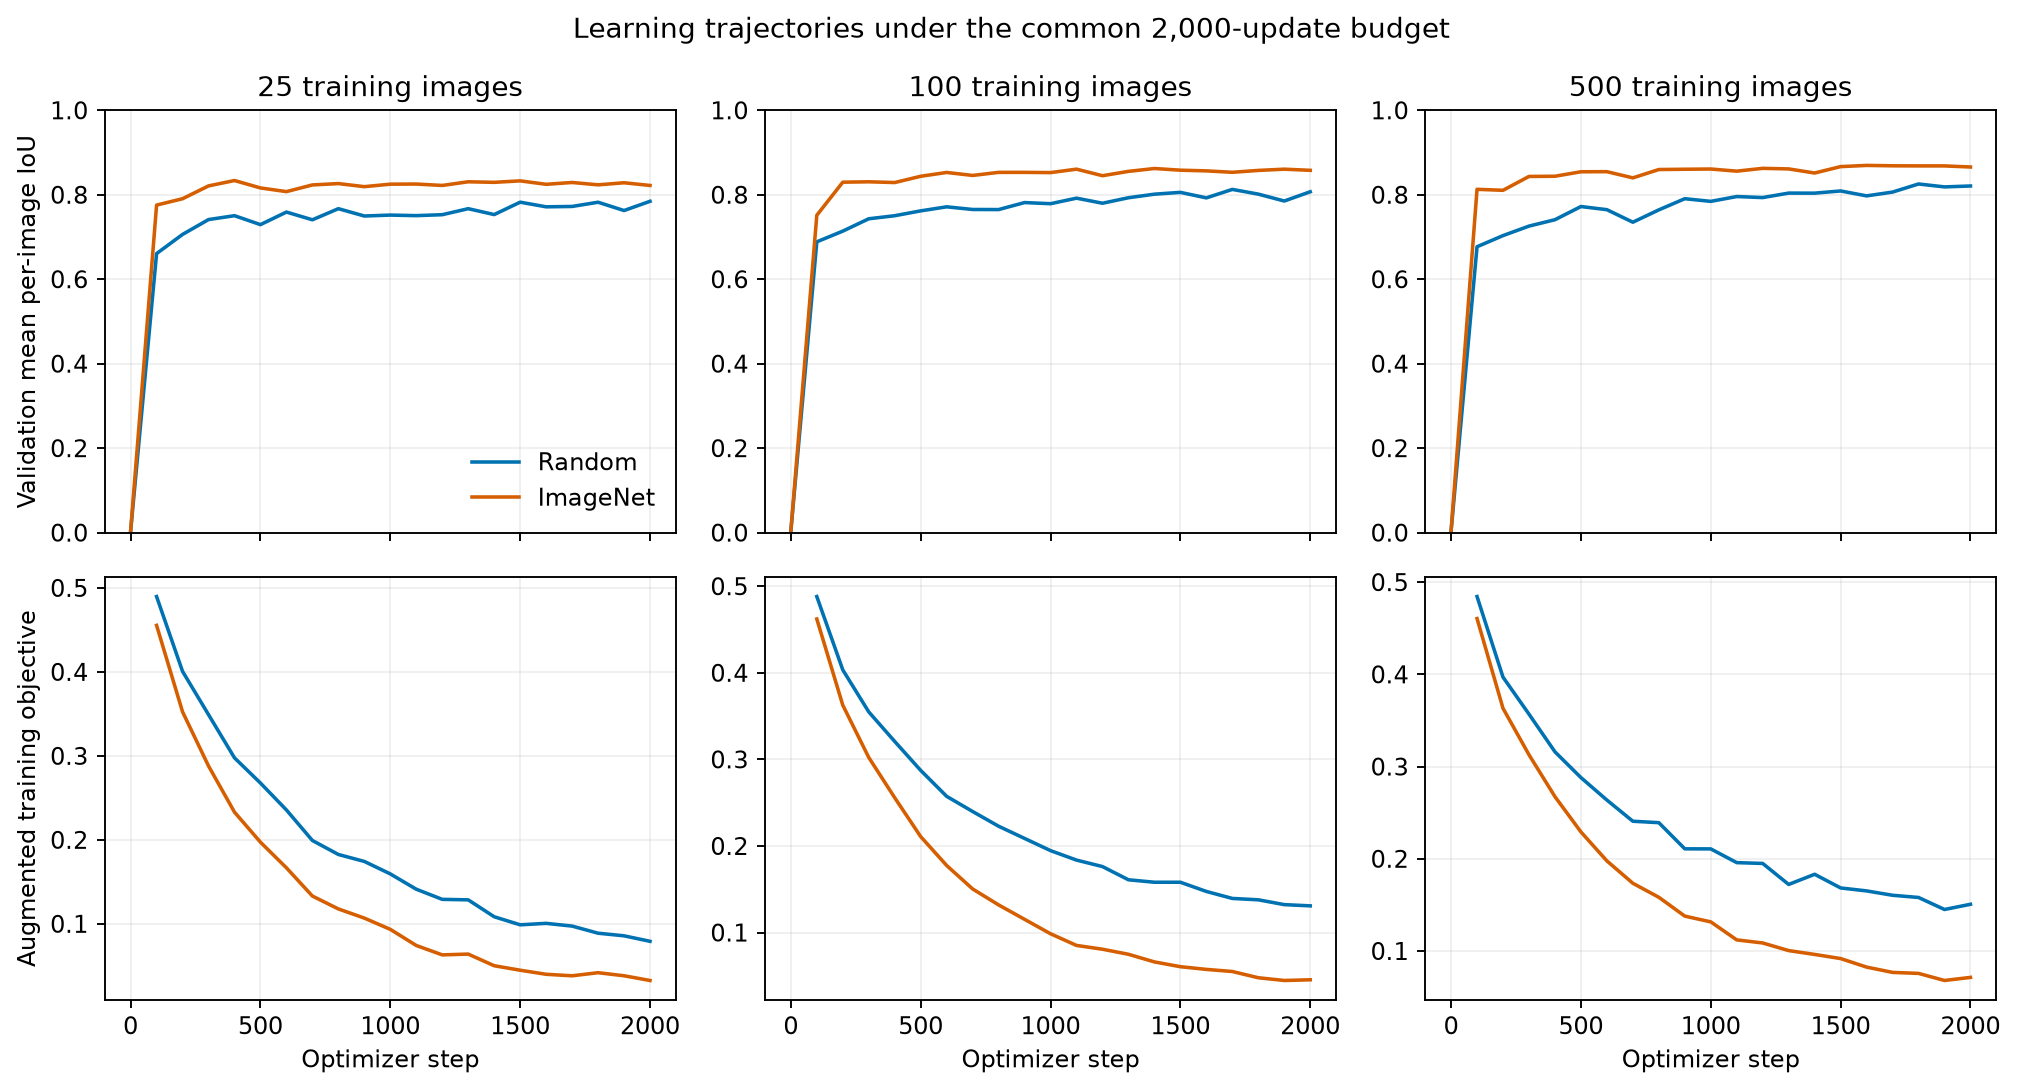

In [4]:
display(Image(filename=ROOT / "reports/figures/training_pilot_learning_curves.png"))

The n=25 ImageNet run reaches its selected checkpoint at step 400 and then loses validation IoU while the training objective continues to fall, which is evidence of overfitting under the long fixed-update budget. The n=25 random run reaches its best value at the final step, so convergence may be incomplete. At n=100 and n=500 the selected steps are later (1,400–1,800); the larger-data curves still improve near the end in places. The shared budget therefore gives a useful common-recipe pilot, but it does not establish that either initialization is optimally trained.

## 4. Paired effect of initialization

Within each training size, both runs share the exact subset, sample order, D4 codes and initial decoder weights. The bars report ImageNet minus random performance at each run's validation-selected checkpoint. This isolates initialization more clearly than unrelated runs, but one subset repetition does not quantify uncertainty.

,iou,dice,ap
training_size,,,
25,+0.049,+0.033,+0.023
100,+0.050,+0.031,+0.003
500,+0.044,+0.027,+0.011


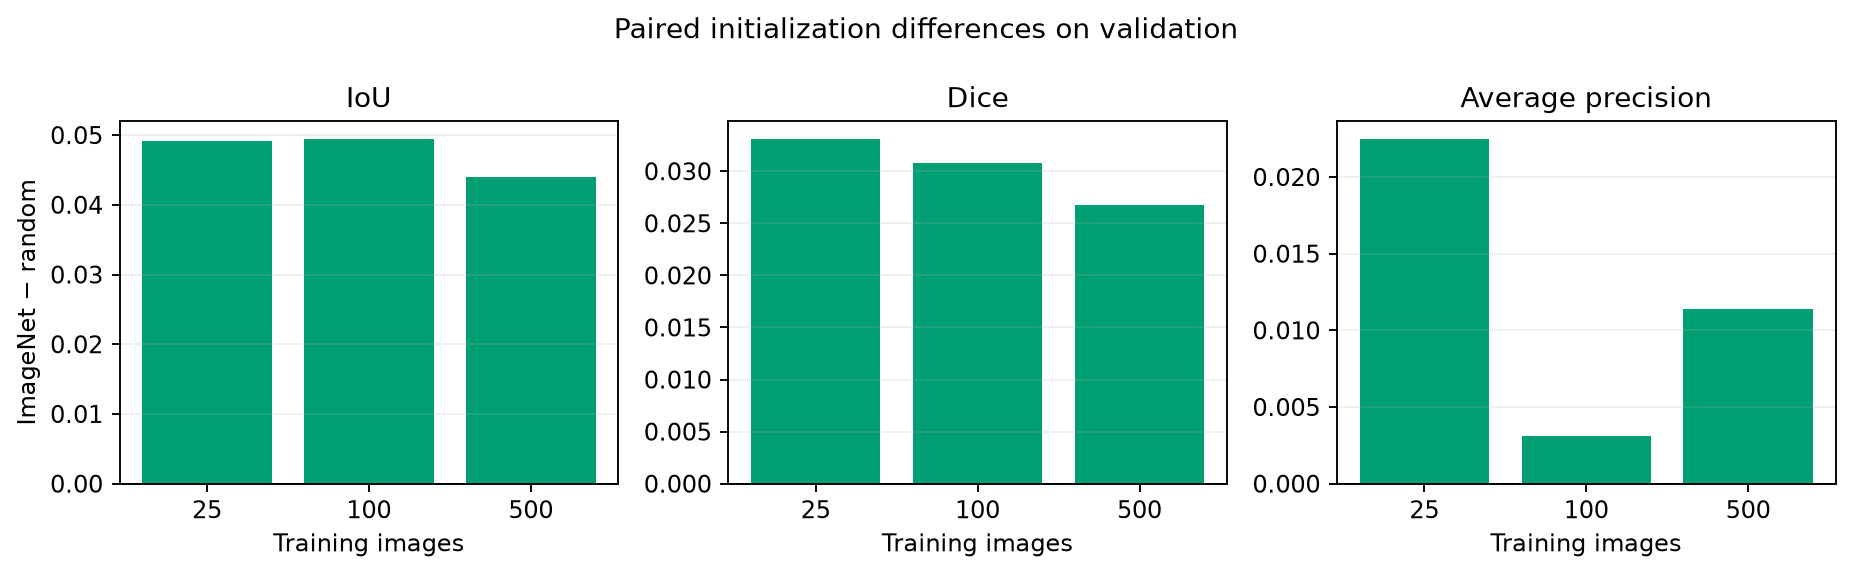

In [5]:
paired = RESULTS.pivot(index="training_size", columns="initialization",
                       values=["validation_iou", "validation_dice", "validation_ap"])
differences = pd.DataFrame({
    metric.removeprefix("validation_"): paired[(metric, "imagenet")] - paired[(metric, "random")]
    for metric in ("validation_iou", "validation_dice", "validation_ap")
})
display(differences.style.format("{:+.3f}"))
display(Image(filename=ROOT / "reports/figures/training_pilot_paired_differences.png"))

ImageNet initialization improves validation IoU by 0.049, 0.050 and 0.044 at 25, 100 and 500 images. Dice improves by 0.033, 0.031 and 0.027, while AP improves by 0.023, 0.003 and 0.011. The direction is consistent across the three paired budgets, but these are three nested subsets from one repetition rather than independent estimates. In particular, the fact that the 25-image ImageNet run slightly exceeds the 500-image random run under this recipe is not an estimate of label equivalence.

## 5. Training versus validation

For each selected checkpoint, both roles are evaluated in model evaluation mode, at original orientation and without augmentation. Their difference is therefore interpretable as a generalization gap. It is distinct from the augmented training objective shown above.

training_size,initialization,training_iou,validation_iou,training_dice,validation_dice,training_ap,validation_ap
25,imagenet,0.934,0.834,0.965,0.904,0.993,0.946
25,random,0.904,0.785,0.949,0.871,0.987,0.924
100,imagenet,0.944,0.862,0.971,0.923,0.995,0.960
100,random,0.834,0.813,0.906,0.892,0.970,0.957
500,imagenet,0.914,0.870,0.953,0.927,0.987,0.975
500,random,0.812,0.826,0.891,0.900,0.957,0.964


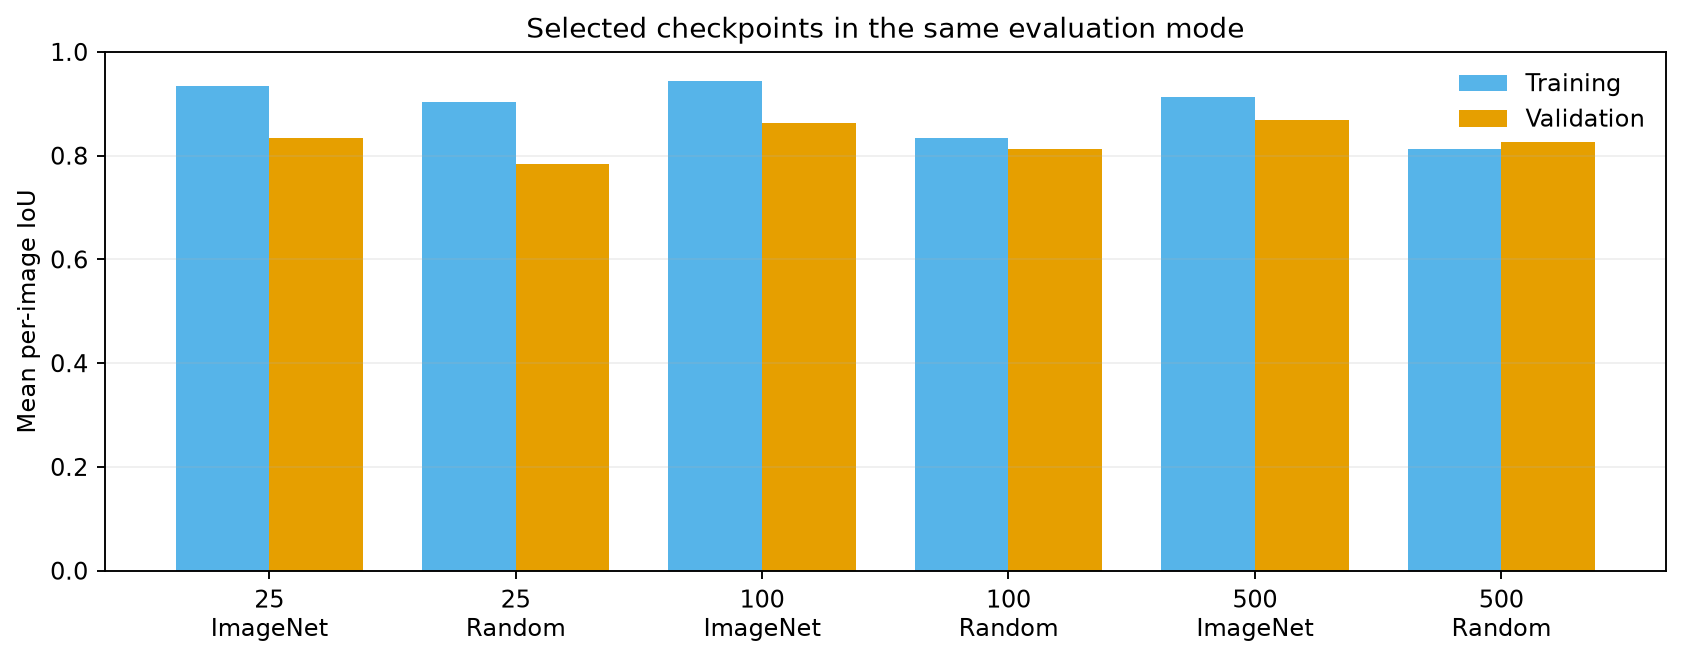

In [6]:
comparison = RESULTS[[
    "training_size", "initialization", "training_iou", "validation_iou",
    "training_dice", "validation_dice", "training_ap", "validation_ap",
]].copy()
display(comparison.style.format({column: "{:.3f}" for column in comparison.columns[2:]}).hide(axis="index"))
display(Image(filename=ROOT / "reports/figures/training_pilot_train_validation.png"))

The selected n=25 checkpoints have the largest training-minus-validation IoU gaps: 0.100 for ImageNet and 0.119 for random initialization. The gaps narrow at larger budgets. The n=500 random run has validation IoU 0.013 above its matched training-subset IoU; spatial composition and per-image averaging can produce this ordering, so it should not be interpreted as negative overfitting. These comparisons use the selected checkpoint and consequently inherit validation-selection bias.

## 6. Common validation cases

The same validation IDs are shown for every training size. They were selected from the n=500 per-image metrics as the lowest paired mean IoU, largest initialization disagreement, highest paired mean IoU and the known empty reference. Error maps use green for true-positive roof pixels, orange for false positives and blue for false negatives. This is validation error analysis; test imagery and predictions remain unopened.

Selected validation IDs: 39, 173, 147


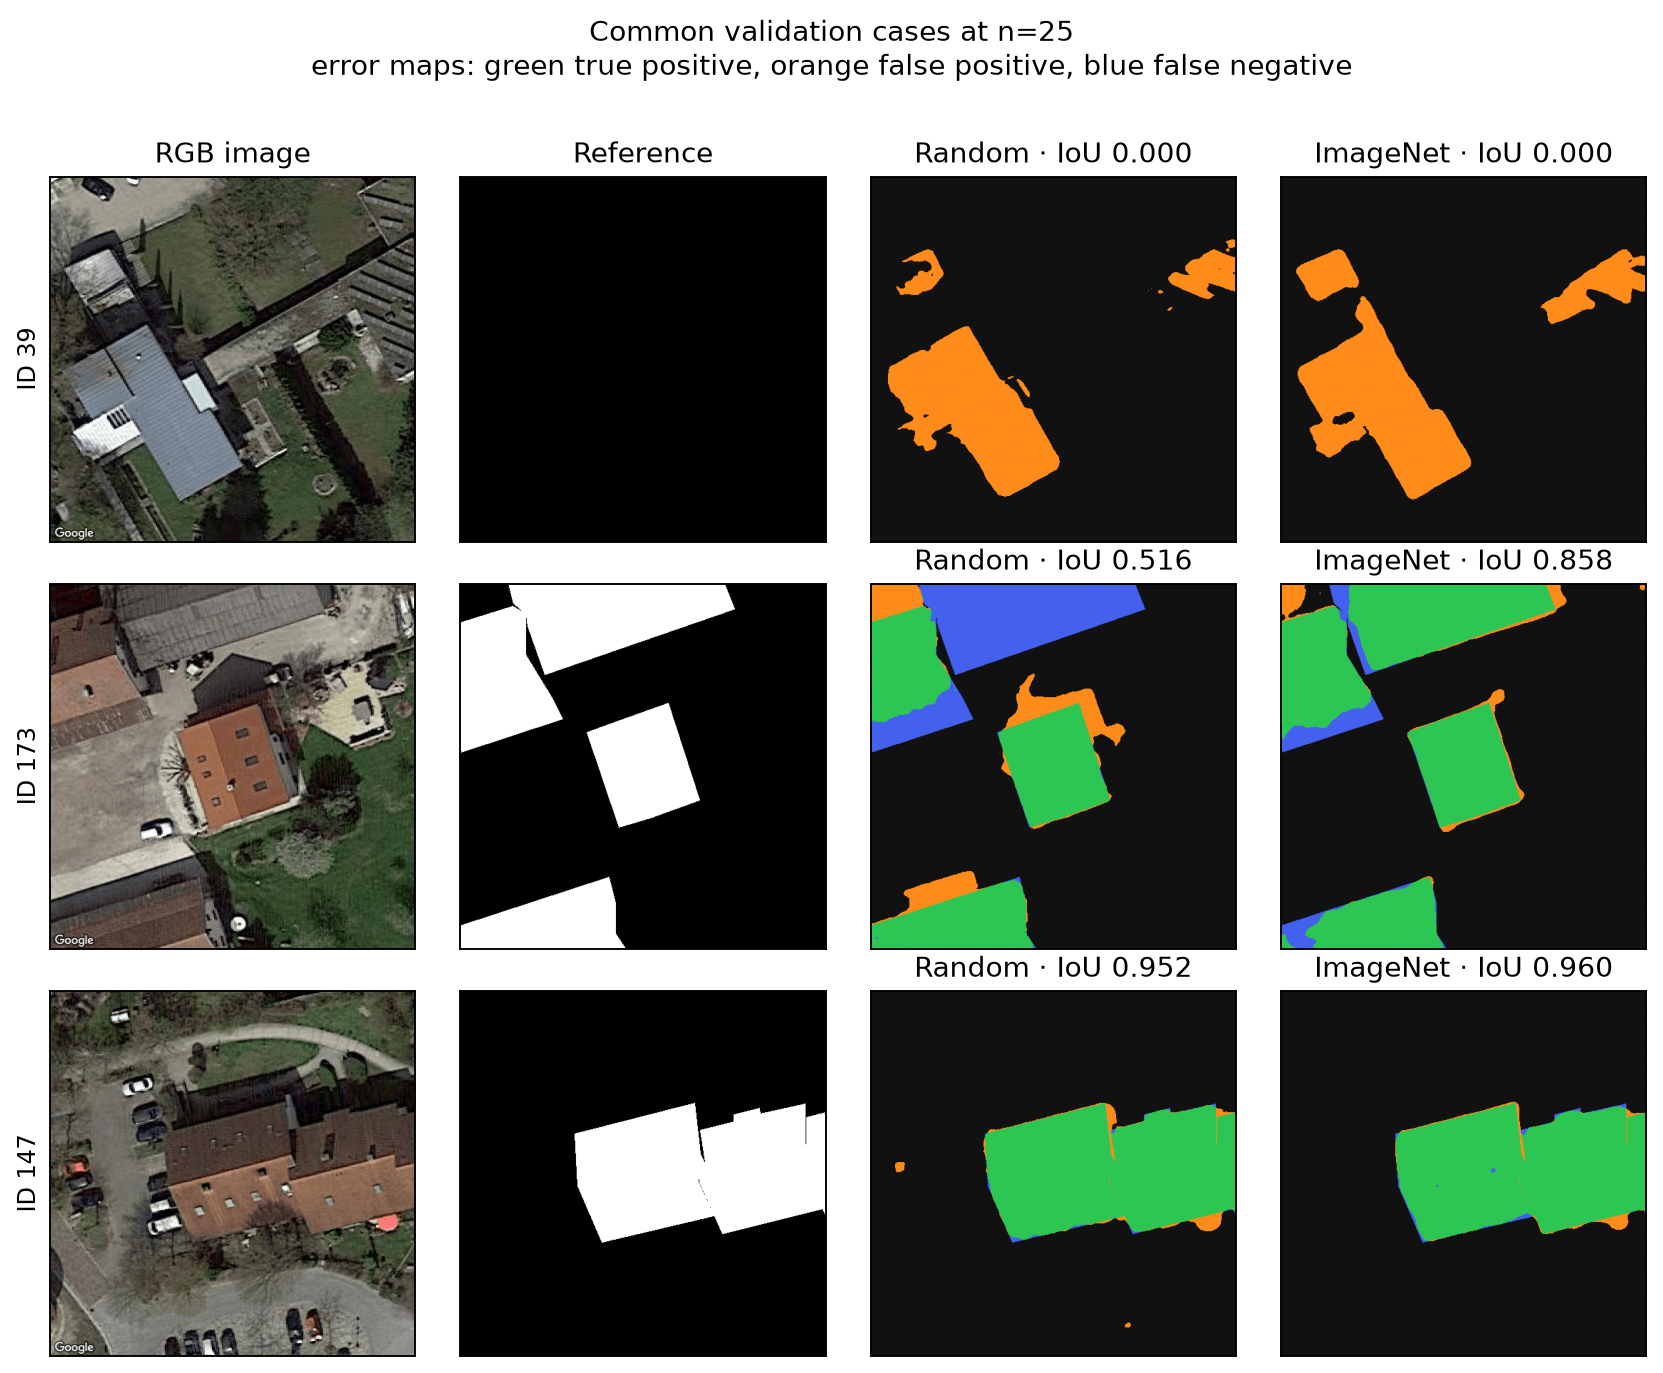

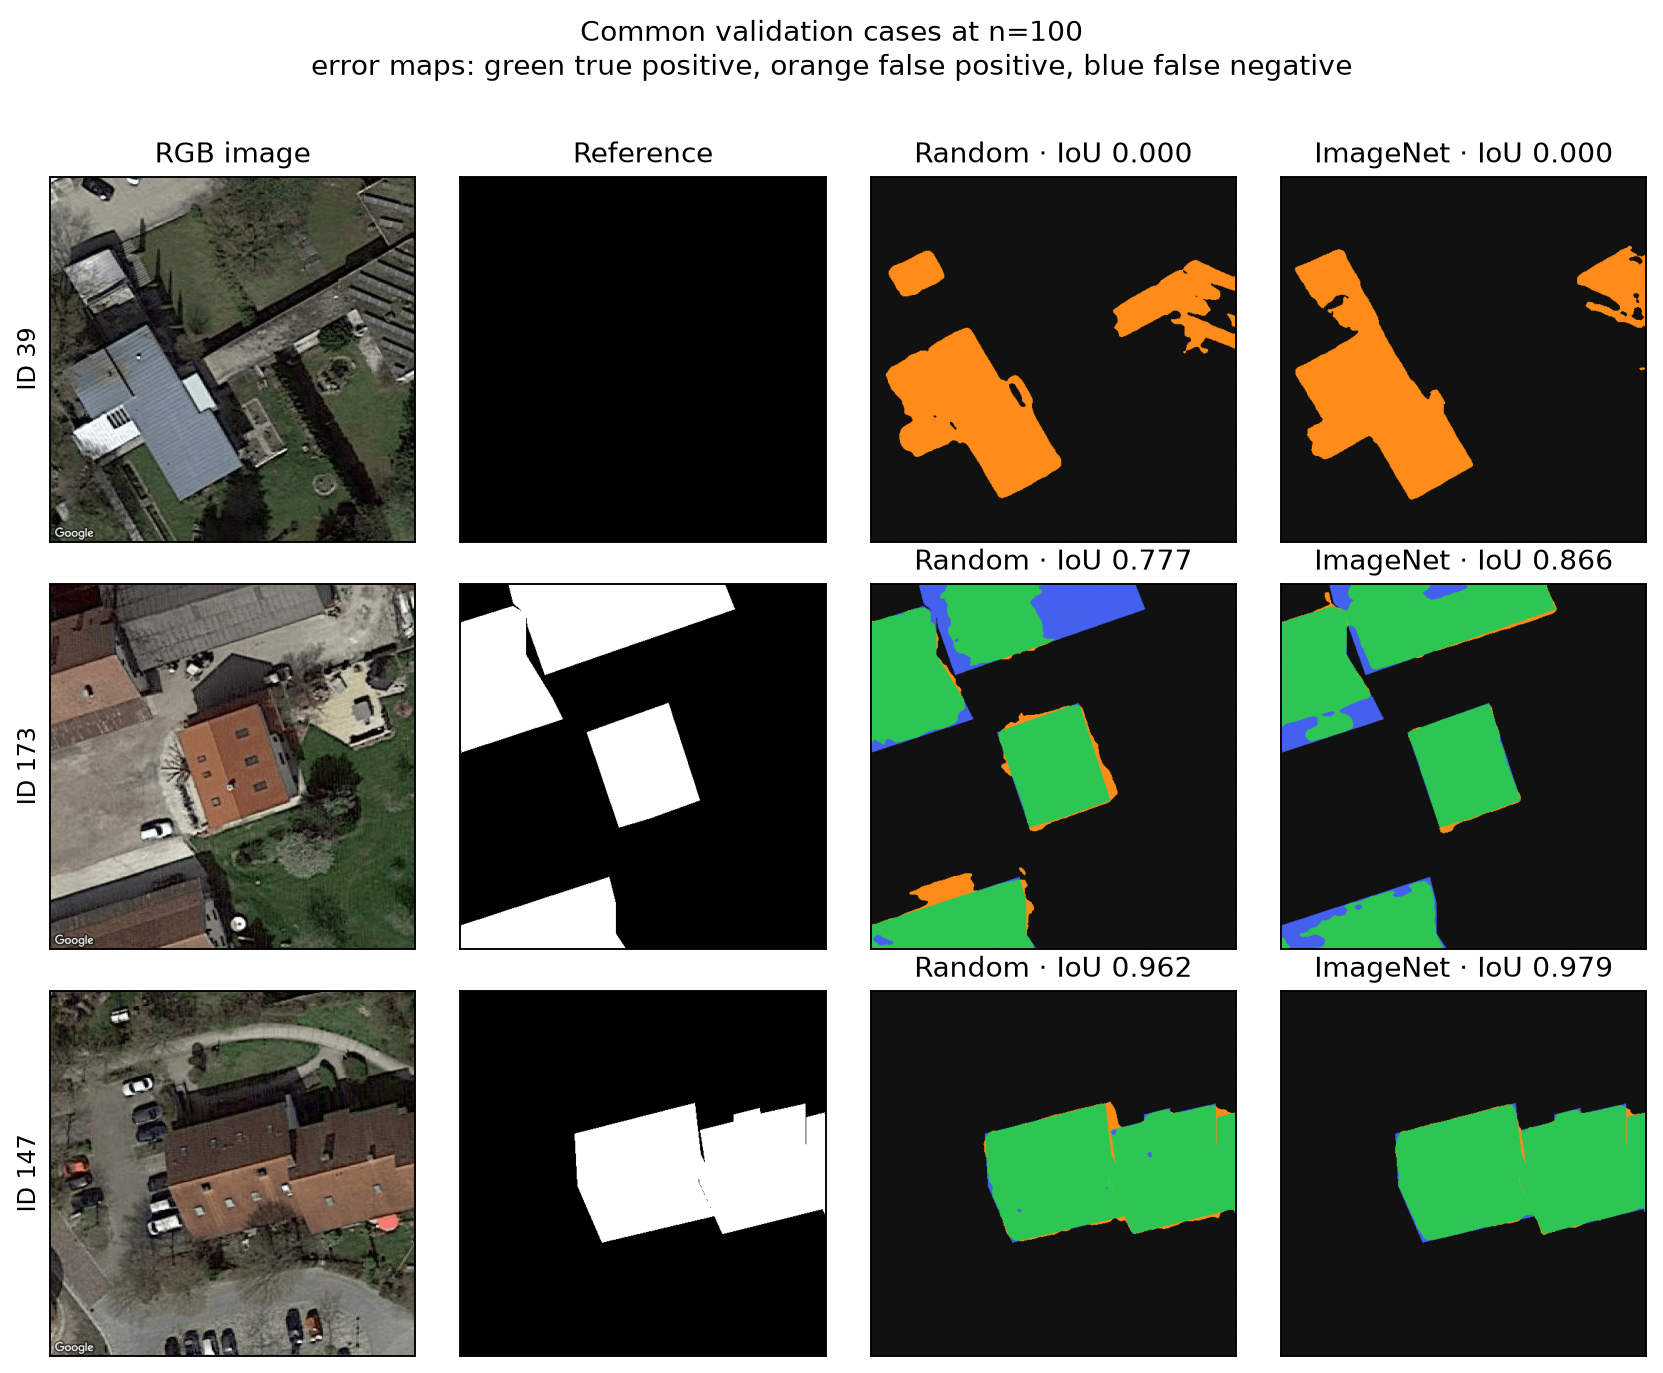

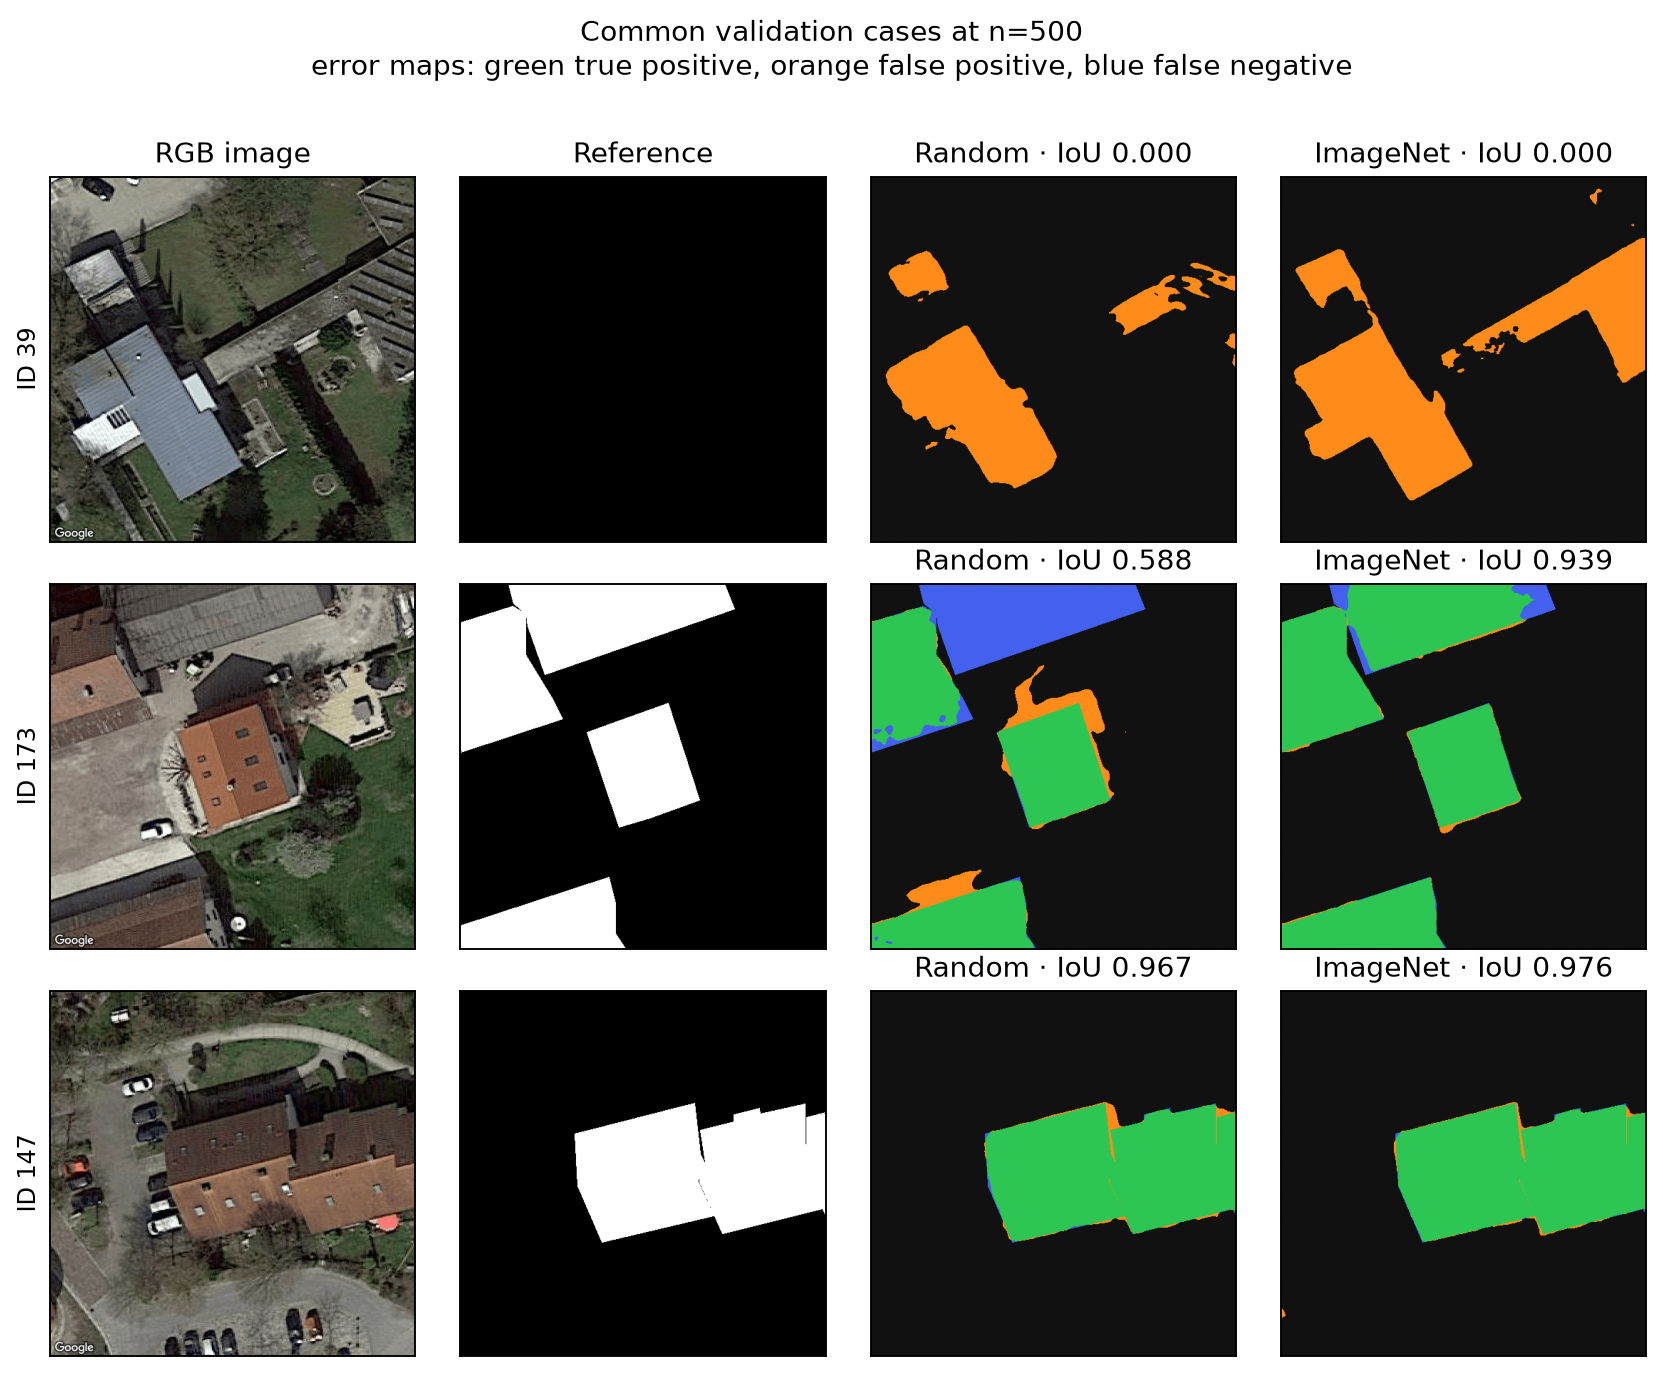

In [7]:
selected_ids = (ROOT / "reports/training_pilot_example_ids.txt").read_text().splitlines()
print("Selected validation IDs:", ", ".join(selected_ids))
for size in (25, 100, 500):
    display(Image(filename=ROOT / f"reports/figures/training_pilot_examples_n{size}.png"))

The four selection criteria yield three unique IDs because the empty-mask case, ID 39, is also the lowest paired-IoU case. Both models predict false-positive roof pixels there, giving IoU 0 under the declared empty-mask rule. ID 173 is the largest n=500 initialization disagreement and shows a substantial reduction in missed roof area for ImageNet initialization. ID 147 is a shared high-IoU case. These examples make failure modes visible, but they were chosen from validation metrics and cannot support an unbiased performance claim.

## 7. Limitations and next decision

Under one paired subset repetition, a common learning rate and the same 2,000-update budget, ImageNet initialization performs better than random initialization at all three label budgets. The evidence supports carrying pretraining forward as a strong candidate, while the curve shapes show that the common recipe does not give equal convergence: the smallest pretrained run overfits early and several other runs select late checkpoints.

The pilot does not measure variation across subset seeds, does not tune either initialization separately and does not evaluate the held-out test region. A limited next block should screen learning rate at n=100 before expanding the study: add 1×10⁻⁴ and 1×10⁻³ for both initializations, paired against the existing 3×10⁻⁴ runs. This requires four new runs, estimated at about 55 minutes on the measured MPS setup. No such run is started here.